# Customer Churn & Retention Intelligence System

## Phase 5 — Model Explainability and Customer Risk Scoring

### Objective

The objective of this phase is to explain the predictions generated by
the tuned XGBoost churn model and convert model probabilities into
actionable customer-risk information.

SHAP is used to understand both global and individual feature
contributions to churn predictions.

The phase also creates customer-level churn probabilities and risk
segments that can later be used for retention prioritisation and
dashboard reporting.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:.4f}"
)

In [4]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

MODEL_DIR = (
    PROJECT_ROOT / "models"
)

print(
    "Processed data directory:",
    PROCESSED_DATA_DIR
)

print(
    "Model directory:",
    MODEL_DIR
)

Processed data directory: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\data\processed
Model directory: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\models


In [5]:
#Load feature dataset
customer_features = pd.read_csv(
    PROCESSED_DATA_DIR
    / "customer_features.csv"
)

print(
    "Customer feature dataset shape:",
    customer_features.shape
)

customer_features.head()

Customer feature dataset shape: (4979, 18)


,Customer ID,Churn,RecencyDays,PurchaseFrequency,MonetaryValue,AverageOrderValue,CustomerTenureDays,UniqueProducts,AverageQuantityPerOrder,MedianPurchaseGap,MeanPurchaseGap,ReturnTransactionCount,ReturnedQuantity,ReturnedValue,IsRepeatCustomer,ReturnTransactionRate,ProductsPerOrder,PurchaseActivityRate
0,13085,0,114.9535,7,2295.3000,327.9000,558.2118,46,128.5714,57.0000,147.6667,2.0000,109.0000,973.8200,1,0.2857,6.5714,0.0125
1,13078,0,20.0285,41,20857.2800,508.7141,558.1556,131,191.2683,12.0000,13.7949,29.0000,105.0000,576.0100,1,0.7073,3.1951,0.0733
2,15362,1,268.0924,2,613.0800,306.5400,558.1542,38,184.0000,290.0000,290.0000,0.0000,0.0000,0.0000,1,0.0000,19.0000,0.0036
3,18102,0,2.8076,102,413459.3700,4053.5232,558.1431,310,1357.7451,7.0000,11.1000,7.0000,1229.0000,7545.8300,1,0.0686,3.0392,0.1824
4,12682,0,11.9708,32,15947.6900,498.3653,558.1403,251,224.7188,15.0000,17.6129,1.0000,9.0000,88.1000,1,0.0312,7.8438,0.0572


In [6]:
#Load saved model and feature list
model_file = (
    MODEL_DIR
    / "tuned_xgboost_churn_model.joblib"
)

feature_file = (
    MODEL_DIR
    / "model_features.csv"
)

xgb_model = joblib.load(
    model_file
)

model_features = (
    pd.read_csv(feature_file)["Feature"]
    .tolist()
)

print(
    "Model loaded successfully."
)

print(
    "Number of model features:",
    len(model_features)
)

print("\nModel features:")

for feature in model_features:
    print("-", feature)

Model loaded successfully.
Number of model features: 16

Model features:
- RecencyDays
- PurchaseFrequency
- MonetaryValue
- AverageOrderValue
- CustomerTenureDays
- UniqueProducts
- AverageQuantityPerOrder
- MedianPurchaseGap
- MeanPurchaseGap
- ReturnTransactionCount
- ReturnedQuantity
- ReturnedValue
- IsRepeatCustomer
- ReturnTransactionRate
- ProductsPerOrder
- PurchaseActivityRate


In [7]:
#Prepare explainability dataset
X_explain = customer_features[
    model_features
].copy()

y_explain = customer_features[
    "Churn"
].copy()

customer_ids = customer_features[
    "Customer ID"
].copy()

print(
    "Explainability feature shape:",
    X_explain.shape
)

print(
    "Target shape:",
    y_explain.shape
)

Explainability feature shape: (4979, 16)
Target shape: (4979,)


## SHAP Model Explainability

SHAP values are used to estimate how each feature contributes to the model's churn prediction.

Global SHAP analysis identifies the features that have the strongest overall influence on churn predictions.

Individual SHAP explanations show why a specific customer's predicted churn risk is pushed higher or lower by their behavioural features.

In [8]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer(
    X_explain
)

print(
    "SHAP values calculated."
)

print(
    "SHAP matrix shape:",
    shap_values.values.shape
)

SHAP values calculated.
SHAP matrix shape: (4979, 16)


## Global SHAP Feature Importance

Global SHAP importance measures the average absolute contribution of each feature across all customer predictions.

A larger mean absolute SHAP value indicates that the feature has a stronger overall influence on the model's churn predictions.

In [9]:
shap_importance = pd.DataFrame({
    "Feature": X_explain.columns,
    "MeanAbsoluteSHAP": np.abs(
        shap_values.values
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "MeanAbsoluteSHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance

,Feature,MeanAbsoluteSHAP
0,RecencyDays,0.6208
1,PurchaseActivityRate,0.2485
2,MonetaryValue,0.2198
3,PurchaseFrequency,0.1762
4,UniqueProducts,0.1748
5,AverageQuantityPerOrder,0.1307
6,MeanPurchaseGap,0.0708
7,MedianPurchaseGap,0.0584
8,ProductsPerOrder,0.0468
9,ReturnTransactionRate,0.0415


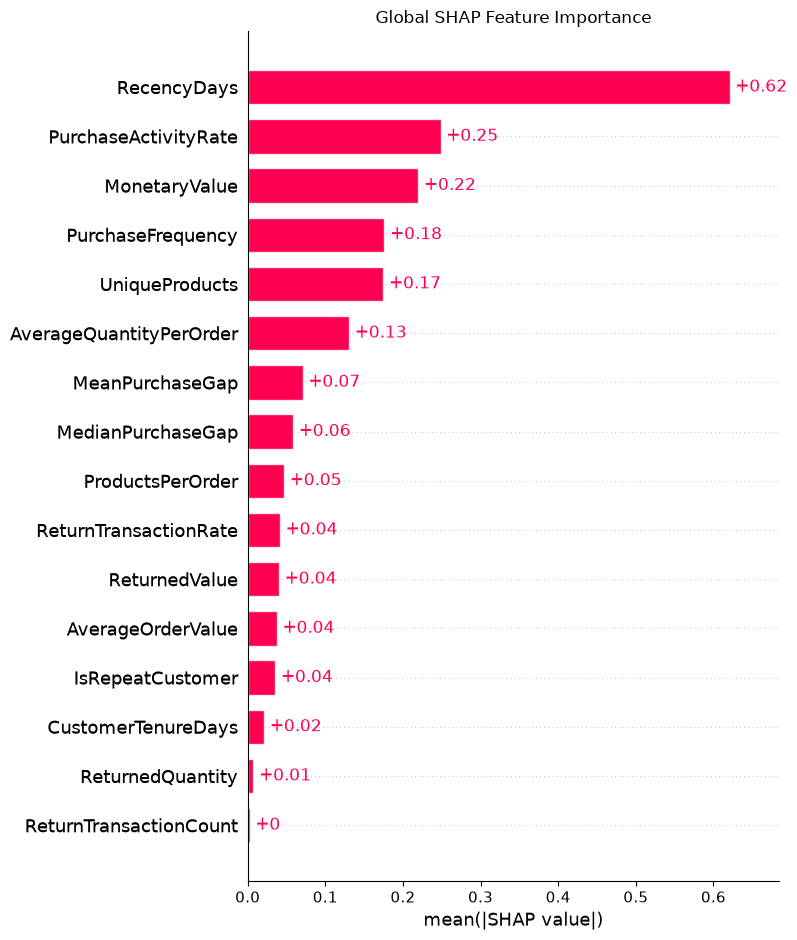

In [10]:
shap.plots.bar(
    shap_values,
    max_display=16,
    show=False
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()
plt.show()

## SHAP Beeswarm Analysis

The SHAP beeswarm plot shows both feature importance and the direction of each feature's effect.

Each point represents one customer.

- Positive SHAP values push the prediction toward churn.
- Negative SHAP values push the prediction toward customer retention.
- Feature colour represents the original feature value, with lower and
  higher feature values shown across the colour scale.

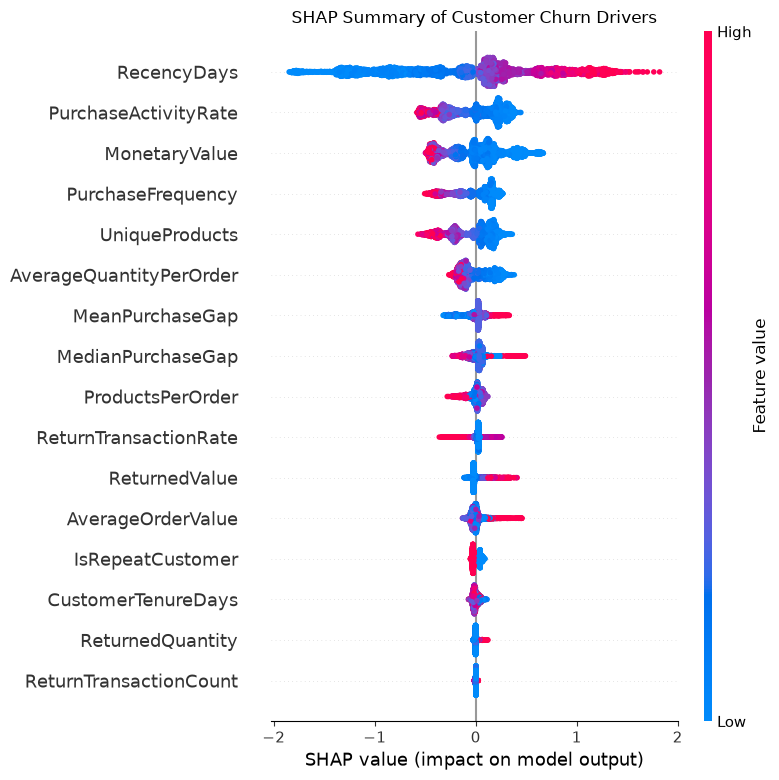

In [11]:
shap.plots.beeswarm(
    shap_values,
    max_display=16,
    show=False
)

plt.title(
    "SHAP Summary of Customer Churn Drivers"
)

plt.tight_layout()
plt.show()

In [12]:
shap_direction = []

for i, feature in enumerate(
    X_explain.columns
):
    correlation = np.corrcoef(
        X_explain[feature],
        shap_values.values[:, i]
    )[0, 1]

    shap_direction.append({
        "Feature": feature,
        "Feature_SHAP_Correlation": correlation
    })

shap_direction = pd.DataFrame(
    shap_direction
).sort_values(
    "Feature_SHAP_Correlation",
    ascending=False
)

shap_direction

,Feature,Feature_SHAP_Correlation
0,RecencyDays,0.9308
8,MeanPurchaseGap,0.5923
3,AverageOrderValue,0.5340
11,ReturnedValue,0.2408
10,ReturnedQuantity,0.1822
9,ReturnTransactionCount,0.0870
7,MedianPurchaseGap,-0.0871
6,AverageQuantityPerOrder,-0.1219
4,CustomerTenureDays,-0.2199
2,MonetaryValue,-0.2607


In [13]:
shap_summary = (
    shap_importance
    .merge(
        shap_direction,
        on="Feature",
        how="left"
    )
)

shap_summary

,Feature,MeanAbsoluteSHAP,Feature_SHAP_Correlation
0,RecencyDays,0.6208,0.9308
1,PurchaseActivityRate,0.2485,-0.4589
2,MonetaryValue,0.2198,-0.2607
3,PurchaseFrequency,0.1762,-0.5668
4,UniqueProducts,0.1748,-0.7447
5,AverageQuantityPerOrder,0.1307,-0.1219
6,MeanPurchaseGap,0.0708,0.5923
7,MedianPurchaseGap,0.0584,-0.0871
8,ProductsPerOrder,0.0468,-0.4811
9,ReturnTransactionRate,0.0415,-0.6760


In [14]:
shap_summary.to_csv(
    PROCESSED_DATA_DIR
    / "shap_feature_summary.csv",
    index=False
)

print(
    "SHAP feature summary saved successfully."
)

SHAP feature summary saved successfully.


## Individual Customer Explanations

Global SHAP analysis explains the model across the complete customer population.

Individual SHAP explanations are used to understand why a specific customer receives a high or low churn prediction.

These explanations can support retention teams by showing the behavioural factors contributing most strongly to each customer's risk score.

In [15]:
customer_risk = customer_features[
    ["Customer ID", "Churn"]
].copy()

customer_risk["ChurnProbability"] = (
    xgb_model.predict_proba(
        X_explain
    )[:, 1]
)

customer_risk = (
    customer_risk
    .sort_values(
        "ChurnProbability",
        ascending=False
    )
    .reset_index(drop=True)
)

customer_risk.head(10)

,Customer ID,Churn,ChurnProbability
0,12918,1,0.9456
1,12860,1,0.9410
2,15760,1,0.9385
3,16908,1,0.9359
4,15375,1,0.9354
5,12466,1,0.9350
6,12404,1,0.9350
7,17352,1,0.9348
8,16397,1,0.9348
9,14832,1,0.9347


In [16]:
customer_risk[
    "ChurnProbability"
].describe()

count   4979.0000
mean       0.4821
std        0.2775
min        0.0153
25%        0.2363
50%        0.5217
75%        0.7084
max        0.9456
Name: ChurnProbability, dtype: float64

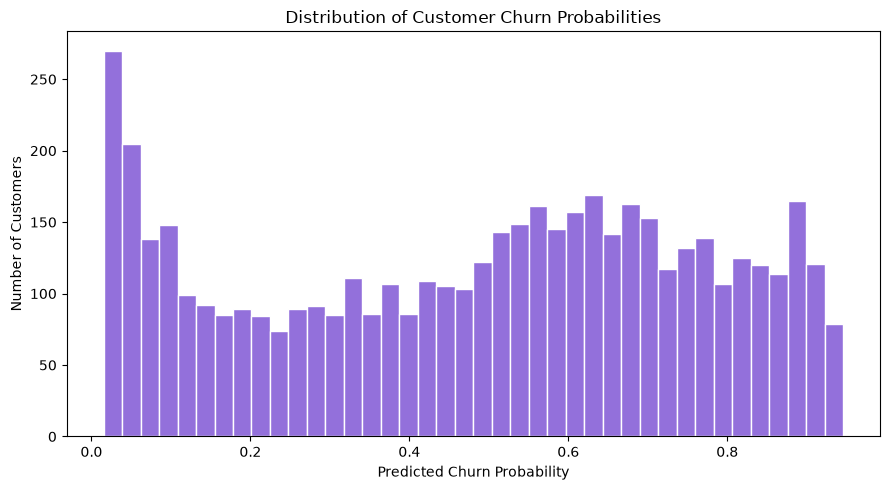

In [17]:
plt.figure(figsize=(9, 5))

plt.hist(
    customer_risk["ChurnProbability"],
    bins=40,
    color="mediumpurple",
    edgecolor="white"
)

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Churn Probabilities")

plt.tight_layout()
plt.show()

In [18]:
highest_risk_customer = (
    customer_risk.iloc[0]
)

highest_risk_id = int(
    highest_risk_customer["Customer ID"]
)

highest_risk_probability = (
    highest_risk_customer[
        "ChurnProbability"
    ]
)

print(
    "Highest-risk Customer ID:",
    highest_risk_id
)

print(
    "Predicted churn probability:",
    f"{highest_risk_probability:.2%}"
)

Highest-risk Customer ID: 12918
Predicted churn probability: 94.56%


In [19]:
high_risk_index = (
    customer_features[
        customer_features["Customer ID"]
        == highest_risk_id
    ].index[0]
)

customer_features.loc[
    high_risk_index
]

Customer ID               12918.0000
Churn                         1.0000
RecencyDays                 445.8944
PurchaseFrequency             1.0000
MonetaryValue             10953.5000
AverageOrderValue         10953.5000
CustomerTenureDays          445.8944
UniqueProducts                1.0000
AverageQuantityPerOrder       1.0000
MedianPurchaseGap            61.0000
MeanPurchaseGap              70.8167
ReturnTransactionCount        2.0000
ReturnedQuantity              2.0000
ReturnedValue             21907.0000
IsRepeatCustomer              0.0000
ReturnTransactionRate         2.0000
ProductsPerOrder              1.0000
PurchaseActivityRate          0.0022
Name: 2017, dtype: float64

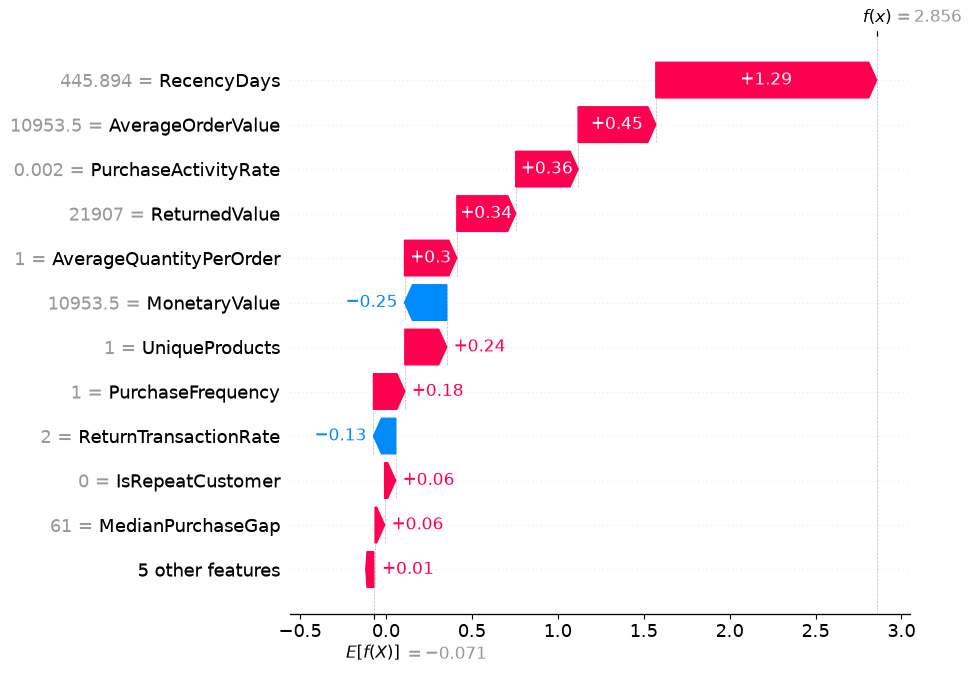

In [ ]:
#SHAP waterfall for high-risk customer
shap.plots.waterfall(
    shap_values[
        high_risk_index
    ],
    max_display=12
)

In [21]:
lowest_risk_customer = (
    customer_risk.iloc[-1]
)

lowest_risk_id = int(
    lowest_risk_customer["Customer ID"]
)

lowest_risk_probability = (
    lowest_risk_customer[
        "ChurnProbability"
    ]
)

print(
    "Lowest-risk Customer ID:",
    lowest_risk_id
)

print(
    "Predicted churn probability:",
    f"{lowest_risk_probability:.2%}"
)

Lowest-risk Customer ID: 15856
Predicted churn probability: 1.53%


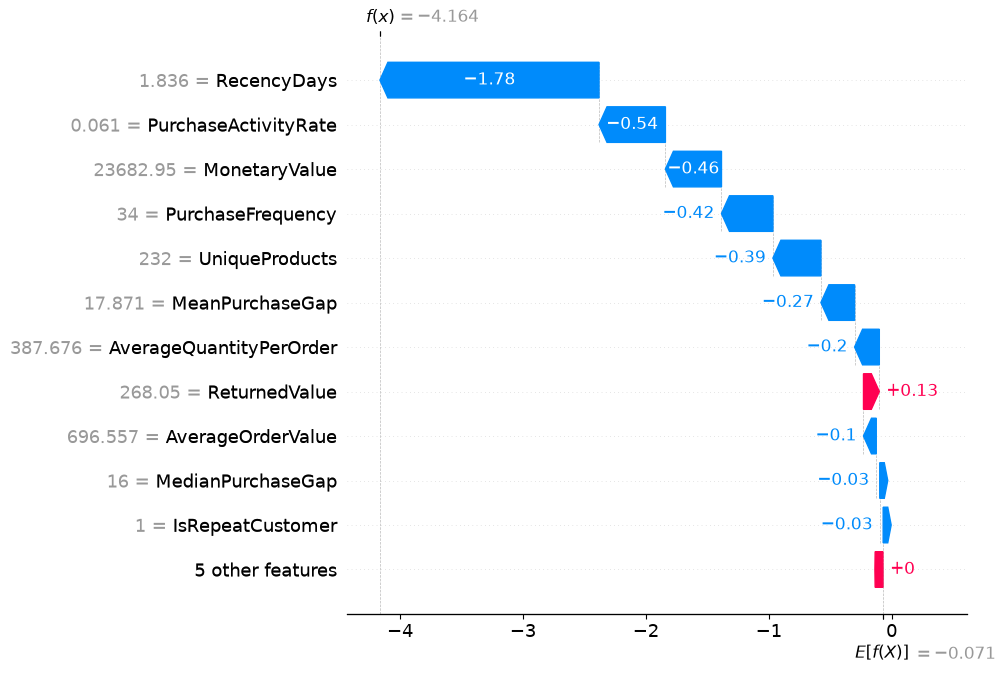

In [ ]:
#SHAP waterfall for low-risk customer
low_risk_index = (
    customer_features[
        customer_features["Customer ID"]
        == lowest_risk_id
    ].index[0]
)

shap.plots.waterfall(
    shap_values[
        low_risk_index
    ],
    max_display=12
)

## Customer Churn Risk Segmentation

Predicted churn probabilities are converted into customer-risk segments to make the model output easier to use for retention prioritisation.

Rather than selecting arbitrary probability thresholds, the initial segments are based on the observed churn-probability distribution.

The 25th, 50th, and 75th percentiles are used to create Low, Medium, High, and Critical risk groups.

In [23]:
risk_thresholds = (
    customer_risk["ChurnProbability"]
    .quantile([0.25, 0.50, 0.75])
)

risk_thresholds

0.2500   0.2363
0.5000   0.5217
0.7500   0.7084
Name: ChurnProbability, dtype: float64

In [24]:
q25 = risk_thresholds.loc[0.25]
q50 = risk_thresholds.loc[0.50]
q75 = risk_thresholds.loc[0.75]

customer_risk["RiskSegment"] = pd.cut(
    customer_risk["ChurnProbability"],
    bins=[
        -np.inf,
        q25,
        q50,
        q75,
        np.inf
    ],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

customer_risk[
    [
        "Customer ID",
        "ChurnProbability",
        "RiskSegment"
    ]
].head(10)

,Customer ID,ChurnProbability,RiskSegment
0,12918,0.9456,Critical
1,12860,0.9410,Critical
2,15760,0.9385,Critical
3,16908,0.9359,Critical
4,15375,0.9354,Critical
5,12466,0.9350,Critical
6,12404,0.9350,Critical
7,17352,0.9348,Critical
8,16397,0.9348,Critical
9,14832,0.9347,Critical


In [25]:
#Check segment distribution
risk_segment_summary = (
    customer_risk["RiskSegment"]
    .value_counts()
    .reindex(
        [
            "Low",
            "Medium",
            "High",
            "Critical"
        ]
    )
)

risk_segment_summary

RiskSegment
Low         1245
Medium      1245
High        1244
Critical    1245
Name: count, dtype: int64

In [26]:
risk_validation = (
    customer_risk
    .groupby(
        "RiskSegment",
        observed=False
    )
    .agg(
        CustomerCount=(
            "Customer ID",
            "count"
        ),
        AverageChurnProbability=(
            "ChurnProbability",
            "mean"
        ),
        ActualChurnRate=(
            "Churn",
            "mean"
        )
    )
)

risk_validation[
    "AverageChurnProbability"
] *= 100

risk_validation[
    "ActualChurnRate"
] *= 100

risk_validation.round(2)

,CustomerCount,AverageChurnProbability,ActualChurnRate
RiskSegment,,,
Low,1245,9.9600,6.9900
Medium,1245,38.9000,36.7900
High,1244,61.6100,64.3100
Critical,1245,82.3900,84.9000


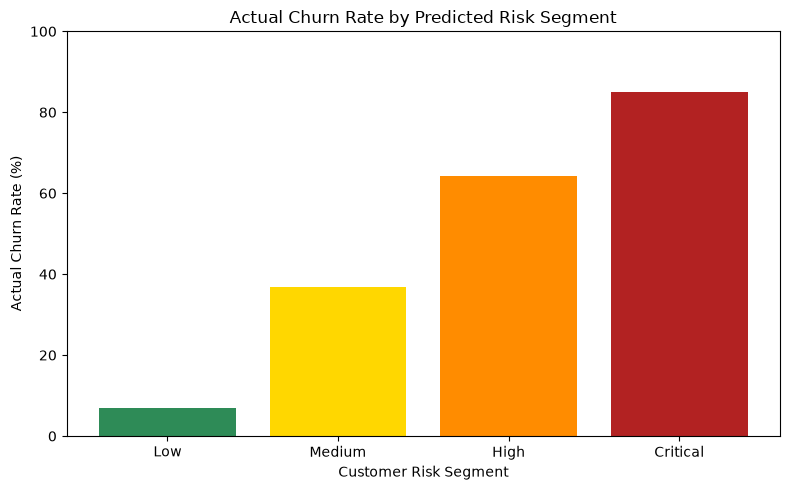

In [27]:
risk_plot = (
    risk_validation
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    risk_plot["RiskSegment"],
    risk_plot["ActualChurnRate"],
    color=[
        "seagreen",
        "gold",
        "darkorange",
        "firebrick"
    ]
)

plt.xlabel("Customer Risk Segment")
plt.ylabel("Actual Churn Rate (%)")
plt.title(
    "Actual Churn Rate by Predicted Risk Segment"
)

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## Retention Priority Analysis

Churn probability identifies customers who are likely to become inactive, but retention resources should also consider customer value.

Risk scores are therefore combined with historical monetary value to identify high-risk, high-value customers who may deserve greater retention priority.

In [28]:
#Merge customer features with risk scores
retention_priority = (
    customer_risk
    .merge(
        customer_features[
            [
                "Customer ID",
                "RecencyDays",
                "PurchaseFrequency",
                "MonetaryValue",
                "UniqueProducts",
                "IsRepeatCustomer"
            ]
        ],
        on="Customer ID",
        how="left"
    )
)

retention_priority.head()

,Customer ID,Churn,ChurnProbability,RiskSegment,RecencyDays,PurchaseFrequency,MonetaryValue,UniqueProducts,IsRepeatCustomer
0,12918,1,0.9456,Critical,445.8944,1,10953.5000,1,0
1,12860,1,0.9410,Critical,512.8944,1,54.2200,16,0
2,15760,1,0.9385,Critical,450.0451,2,13916.3400,1,0
3,16908,1,0.9359,Critical,541.9688,1,252.5900,20,0
4,15375,1,0.9354,Critical,509.8833,1,60.9600,6,0


In [29]:
value_threshold = (
    retention_priority[
        "MonetaryValue"
    ]
    .quantile(0.75)
)

print(
    "Top 25% monetary-value threshold:",
    round(value_threshold, 2)
)

retention_priority[
    "HighValueCustomer"
] = (
    retention_priority[
        "MonetaryValue"
    ]
    >= value_threshold
).astype(int)

Top 25% monetary-value threshold: 1960.3


In [30]:
def assign_retention_priority(row):

    if (
        row["RiskSegment"] == "Critical"
        and row["HighValueCustomer"] == 1
    ):
        return "Immediate Action"

    elif row["RiskSegment"] == "Critical":
        return "High Priority"

    elif (
        row["RiskSegment"] == "High"
        and row["HighValueCustomer"] == 1
    ):
        return "High Priority"

    elif row["RiskSegment"] == "High":
        return "Medium Priority"

    else:
        return "Monitor"


retention_priority[
    "RetentionPriority"
] = retention_priority.apply(
    assign_retention_priority,
    axis=1
)

In [31]:
retention_priority[
    "RetentionPriority"
].value_counts()

RetentionPriority
Monitor             2490
High Priority       1278
Medium Priority     1184
Immediate Action      27
Name: count, dtype: int64

In [32]:
top_retention_targets = (
    retention_priority[
        retention_priority[
            "RetentionPriority"
        ].isin(
            [
                "Immediate Action",
                "High Priority"
            ]
        )
    ]
    .sort_values(
        [
            "RetentionPriority",
            "ChurnProbability",
            "MonetaryValue"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
)

top_retention_targets[
    [
        "Customer ID",
        "ChurnProbability",
        "RiskSegment",
        "MonetaryValue",
        "RecencyDays",
        "PurchaseFrequency",
        "IsRepeatCustomer",
        "RetentionPriority"
    ]
].head(20)

,Customer ID,ChurnProbability,RiskSegment,MonetaryValue,RecencyDays,PurchaseFrequency,IsRepeatCustomer,RetentionPriority
1,12860,0.9410,Critical,54.2200,512.8944,1,0,High Priority
3,16908,0.9359,Critical,252.5900,541.9688,1,0,High Priority
4,15375,0.9354,Critical,60.9600,509.8833,1,0,High Priority
6,12404,0.9350,Critical,63.2400,501.8507,1,0,High Priority
5,12466,0.9350,Critical,56.7300,501.8500,1,0,High Priority
7,17352,0.9348,Critical,36.2500,515.8590,1,0,High Priority
8,16397,0.9348,Critical,123.1300,447.8847,1,0,High Priority
9,14832,0.9347,Critical,322.6900,449.9000,1,0,High Priority
10,12568,0.9343,Critical,70.0000,464.1493,1,0,High Priority
11,17933,0.9340,Critical,114.6900,451.9021,1,0,High Priority


In [33]:
priority_order = [
    "Immediate Action",
    "High Priority",
    "Medium Priority",
    "Monitor"
]

retention_priority["RetentionPriority"] = pd.Categorical(
    retention_priority["RetentionPriority"],
    categories=priority_order,
    ordered=True
)

In [34]:
top_retention_targets = (
    retention_priority
    .sort_values(
        [
            "RetentionPriority",
            "ChurnProbability",
            "MonetaryValue"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
)

top_retention_targets[
    [
        "Customer ID",
        "ChurnProbability",
        "RiskSegment",
        "MonetaryValue",
        "RecencyDays",
        "PurchaseFrequency",
        "IsRepeatCustomer",
        "RetentionPriority"
    ]
].head(20)

,Customer ID,ChurnProbability,RiskSegment,MonetaryValue,RecencyDays,PurchaseFrequency,IsRepeatCustomer,RetentionPriority
0,12918,0.9456,Critical,10953.5000,445.8944,1,0,Immediate Action
2,15760,0.9385,Critical,13916.3400,450.0451,2,0,Immediate Action
59,16077,0.9259,Critical,2300.4000,445.0889,1,0,Immediate Action
126,13091,0.9125,Critical,1976.0000,549.0042,2,0,Immediate Action
136,13902,0.9108,Critical,34095.2600,451.9868,5,1,Immediate Action
191,17305,0.9004,Critical,2135.4600,468.0021,1,0,Immediate Action
301,14091,0.8836,Critical,9530.0800,473.8979,2,1,Immediate Action
396,14028,0.8692,Critical,10396.5000,369.9701,3,0,Immediate Action
398,12737,0.8690,Critical,3710.5000,318.0146,2,0,Immediate Action
422,13734,0.8630,Critical,6695.6900,328.0319,4,1,Immediate Action


In [35]:
immediate_action_customers = retention_priority[
    retention_priority["RetentionPriority"]
    == "Immediate Action"
].copy()

print(
    "Immediate Action customers:",
    len(immediate_action_customers)
)

print(
    "Average churn probability:",
    f"{immediate_action_customers['ChurnProbability'].mean():.2%}"
)

print(
    "Average monetary value:",
    round(
        immediate_action_customers["MonetaryValue"].mean(),
        2
    )
)

immediate_action_customers[
    [
        "Customer ID",
        "ChurnProbability",
        "MonetaryValue",
        "RecencyDays",
        "PurchaseFrequency",
        "RiskSegment"
    ]
].sort_values(
    "ChurnProbability",
    ascending=False
).head(15)

Immediate Action customers: 27
Average churn probability: 82.41%
Average monetary value: 6489.77


,Customer ID,ChurnProbability,MonetaryValue,RecencyDays,PurchaseFrequency,RiskSegment
0,12918,0.9456,10953.5000,445.8944,1,Critical
2,15760,0.9385,13916.3400,450.0451,2,Critical
59,16077,0.9259,2300.4000,445.0889,1,Critical
126,13091,0.9125,1976.0000,549.0042,2,Critical
136,13902,0.9108,34095.2600,451.9868,5,Critical
191,17305,0.9004,2135.4600,468.0021,1,Critical
301,14091,0.8836,9530.0800,473.8979,2,Critical
396,14028,0.8692,10396.5000,369.9701,3,Critical
398,12737,0.8690,3710.5000,318.0146,2,Critical
422,13734,0.8630,6695.6900,328.0319,4,Critical


In [36]:
retention_priority.to_csv(
    PROCESSED_DATA_DIR
    / "customer_churn_risk_scores.csv",
    index=False
)

print(
    "Customer churn risk scores saved successfully."
)

Customer churn risk scores saved successfully.


In [37]:
top_retention_targets.to_csv(
    PROCESSED_DATA_DIR
    / "retention_priority_customers.csv",
    index=False
)

print(
    "Retention priority dataset saved successfully."
)

Retention priority dataset saved successfully.


In [38]:
files_to_check = [
    "shap_feature_summary.csv",
    "customer_churn_risk_scores.csv",
    "retention_priority_customers.csv"
]

for filename in files_to_check:

    path = (
        PROCESSED_DATA_DIR
        / filename
    )

    print(
        filename,
        "->",
        "Saved" if path.exists() else "Missing"
    )

shap_feature_summary.csv -> Saved
customer_churn_risk_scores.csv -> Saved
retention_priority_customers.csv -> Saved


## Summary

SHAP explainability was applied to the tuned XGBoost churn model to understand the factors influencing customer predictions.

Recency was identified as the strongest overall churn driver. Longer customer inactivity generally increased churn risk, while stronger
purchase activity, higher purchase frequency, greater product diversity, and repeat purchasing behaviour generally reduced risk.

Customer-level churn probabilities were generated for all 4,979 customers.

The probability distribution was divided into four risk segments:

- Low
- Medium
- High
- Critical

The segments showed clear separation in actual churn behaviour:

- Low Risk: 6.99% actual churn
- Medium Risk: 36.79%
- High Risk: 64.31%
- Critical Risk: 84.90%

Churn risk was then combined with historical customer value to create retention-priority groups.

The highest-priority group contains customers with both Critical churn risk and high historical monetary value, allowing retention teams to
focus resources on customers with the greatest potential business impact.

Customer risk scores and retention-priority datasets were saved for dashboarding and downstream deployment. 

In [2]:
from pathlib import Path 
import matplotlib.pyplot as plt 
import pandas as pd 
# Output folder 
FIGURE_DIR = Path("../reports/figures") 
FIGURE_DIR.mkdir(parents=True, exist_ok=True) 
risk_df = pd.read_csv("../data/processed/customer_churn_risk_scores.csv") 
print("Risk columns:") 
print(risk_df.columns.tolist())

Risk columns:
['Customer ID', 'Churn', 'ChurnProbability', 'RiskSegment', 'RecencyDays', 'PurchaseFrequency', 'MonetaryValue', 'UniqueProducts', 'IsRepeatCustomer', 'HighValueCustomer', 'RetentionPriority']


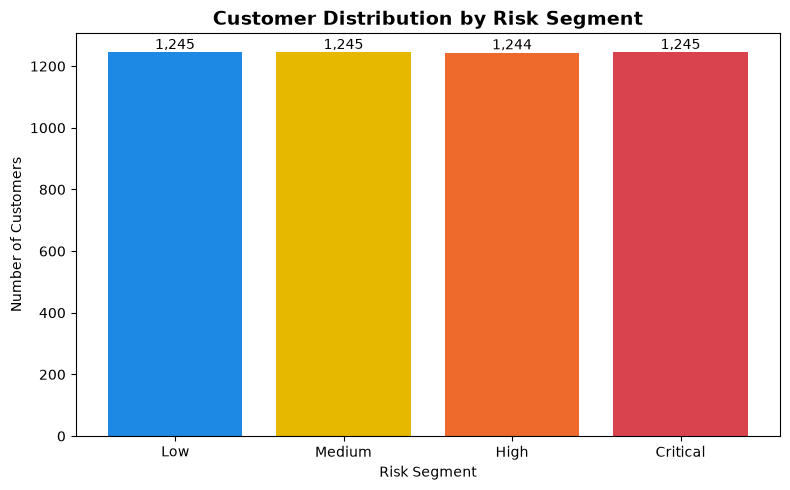

Saved: reports/figures/02_risk_segment_distribution.png


In [3]:
# Figure 2: Risk Segment Distribution

risk_order = ["Low", "Medium", "High", "Critical"]

risk_counts = (
    risk_df["RiskSegment"]
    .value_counts()
    .reindex(risk_order)
    .fillna(0)
)

risk_colors = [
    "#1E88E5",  # Low - blue
    "#E6B800",  # Medium - yellow
    "#ED6A2C",  # High - orange
    "#D9434E"   # Critical - red
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    risk_counts.index,
    risk_counts.values,
    color=risk_colors
)

plt.title("Customer Distribution by Risk Segment",
          fontsize=14,
          fontweight="bold")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "02_risk_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: reports/figures/02_risk_segment_distribution.png")

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# Figure 5: Top Churn Drivers by SHAP Importance

shap_df = pd.read_csv("../data/processed/shap_feature_summary.csv")

print("SHAP columns:")
print(shap_df.columns.tolist())

shap_df.head()

SHAP columns:
['Feature', 'MeanAbsoluteSHAP', 'Feature_SHAP_Correlation']


,Feature,MeanAbsoluteSHAP,Feature_SHAP_Correlation
0,RecencyDays,0.6208,0.9308
1,PurchaseActivityRate,0.2485,-0.4589
2,MonetaryValue,0.2198,-0.2607
3,PurchaseFrequency,0.1762,-0.5668
4,UniqueProducts,0.1748,-0.7447


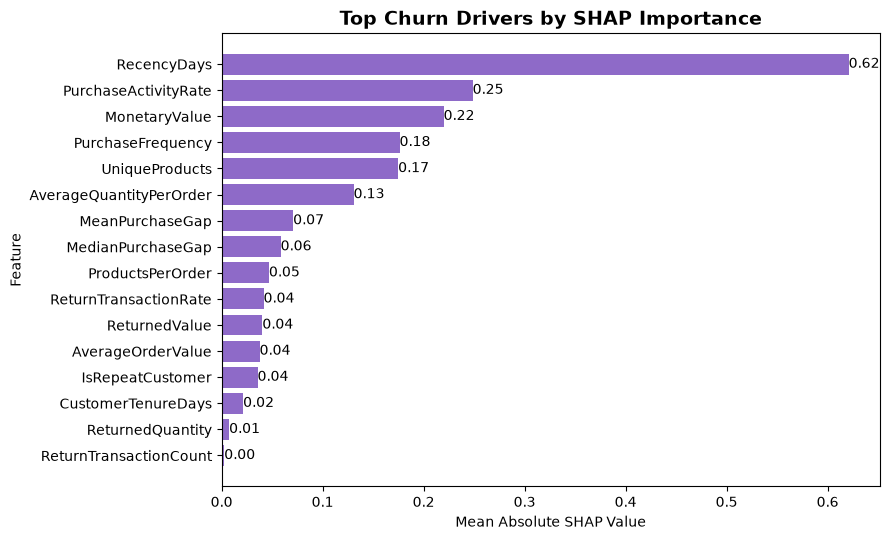

Saved: reports/figures/05_shap_feature_importance.png


In [6]:
# Figure 5: SHAP Feature Importance

shap_plot_df = (
    shap_df
    .sort_values("MeanAbsoluteSHAP", ascending=True)
    .copy()
)

plt.figure(figsize=(9, 5.5))

bars = plt.barh(
    shap_plot_df["Feature"],
    shap_plot_df["MeanAbsoluteSHAP"],
    color="#8E6AC8"
)

plt.title(
    "Top Churn Drivers by SHAP Importance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        ha="left"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "05_shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: reports/figures/05_shap_feature_importance.png")

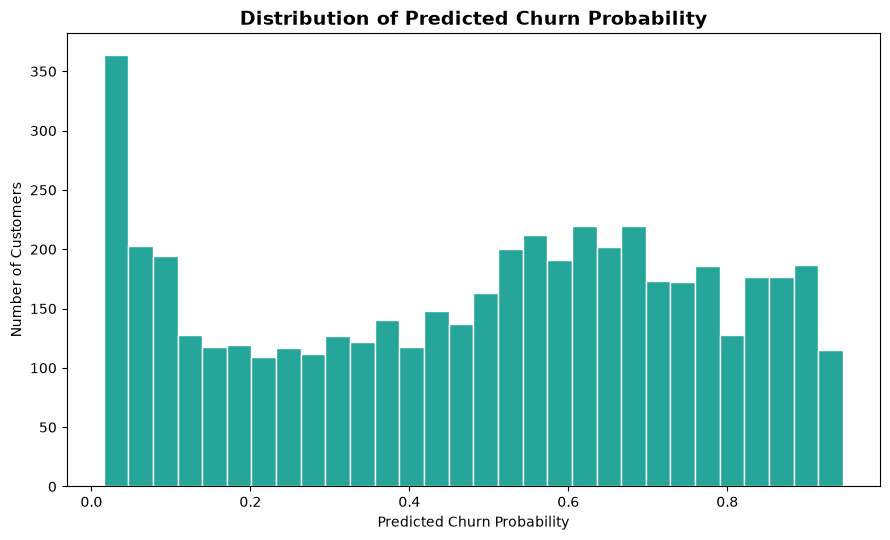

Saved: reports/figures/06_churn_probability_distribution.png


In [7]:
# Figure 6: Churn Probability Distribution

risk_df = pd.read_csv(
    "../data/processed/customer_churn_risk_scores.csv"
)

plt.figure(figsize=(9, 5.5))

plt.hist(
    risk_df["ChurnProbability"],
    bins=30,
    color="#26A69A",
    edgecolor="white"
)

plt.title(
    "Distribution of Predicted Churn Probability",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "06_churn_probability_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: reports/figures/"
    "06_churn_probability_distribution.png"
)